# Predicting Median House Values

 ## Data set Attributes

 The data set contains information about houses in Boston, Massachusetts. The data set was collected by the U.S. Census Service and first published by Harrison and Rubenfeld in 1978.

 It contains the following variables:
* **crim:** per capita crime rate by town
* **zn:** proportion of residential land zoned for lots over 25,000 sq. ft
* **indus:** proportion of non-retail business acres per town
* **chas:** Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
* **nox:** nitric oxide concentration (parts per 10 million)
* **rm:** average number of rooms per dwelling
* **age:** proportion of owner-occupied units built prior to 1940
* **dis:** weighted distances to five boston employment centers
* **rad:** index of accessibility to radial highways
* **tax:** full-value property tax rate per \$10,000
* **ptratio:** pupil-teacher ratio by town
* **b:** 1000(bk — 0.63)², where bk is the proportion of [people of African American descent] by town
* **lstat:** percentage of lower status of the population
* **medv:** median value of owner-occupied homes in $1000s


*Harrison, David, and Daniel L. Rubinfeld, Hedonic Housing Prices and the Demand for Clean Air, Journal of Environmental Economics and Management, Volume 5, (1978), 81-102. Original data.*


## How to Run This Project

### Requirements
This project requires **Python 3.8+** and the following Python packages:

- numpy
- pandas
- matplotlib
- seaborn
- scikit-learn

### Installation
If you do not already have these packages installed, run the following command in your terminal:

```bash
python -m pip install numpy pandas matplotlib seaborn scikit-learn



 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the median value based on the 'lm' and 'lstat` variables.


In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

: 

In [2]:
# Read in the data set
data_boston = pd.read_csv('boston.csv')

In [3]:
# Clean and pre-process the data if neccessary
null_values = data_boston.isnull().sum()
print(null_values)

# There are no null values in the dataframe therefore we can proceed 


crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


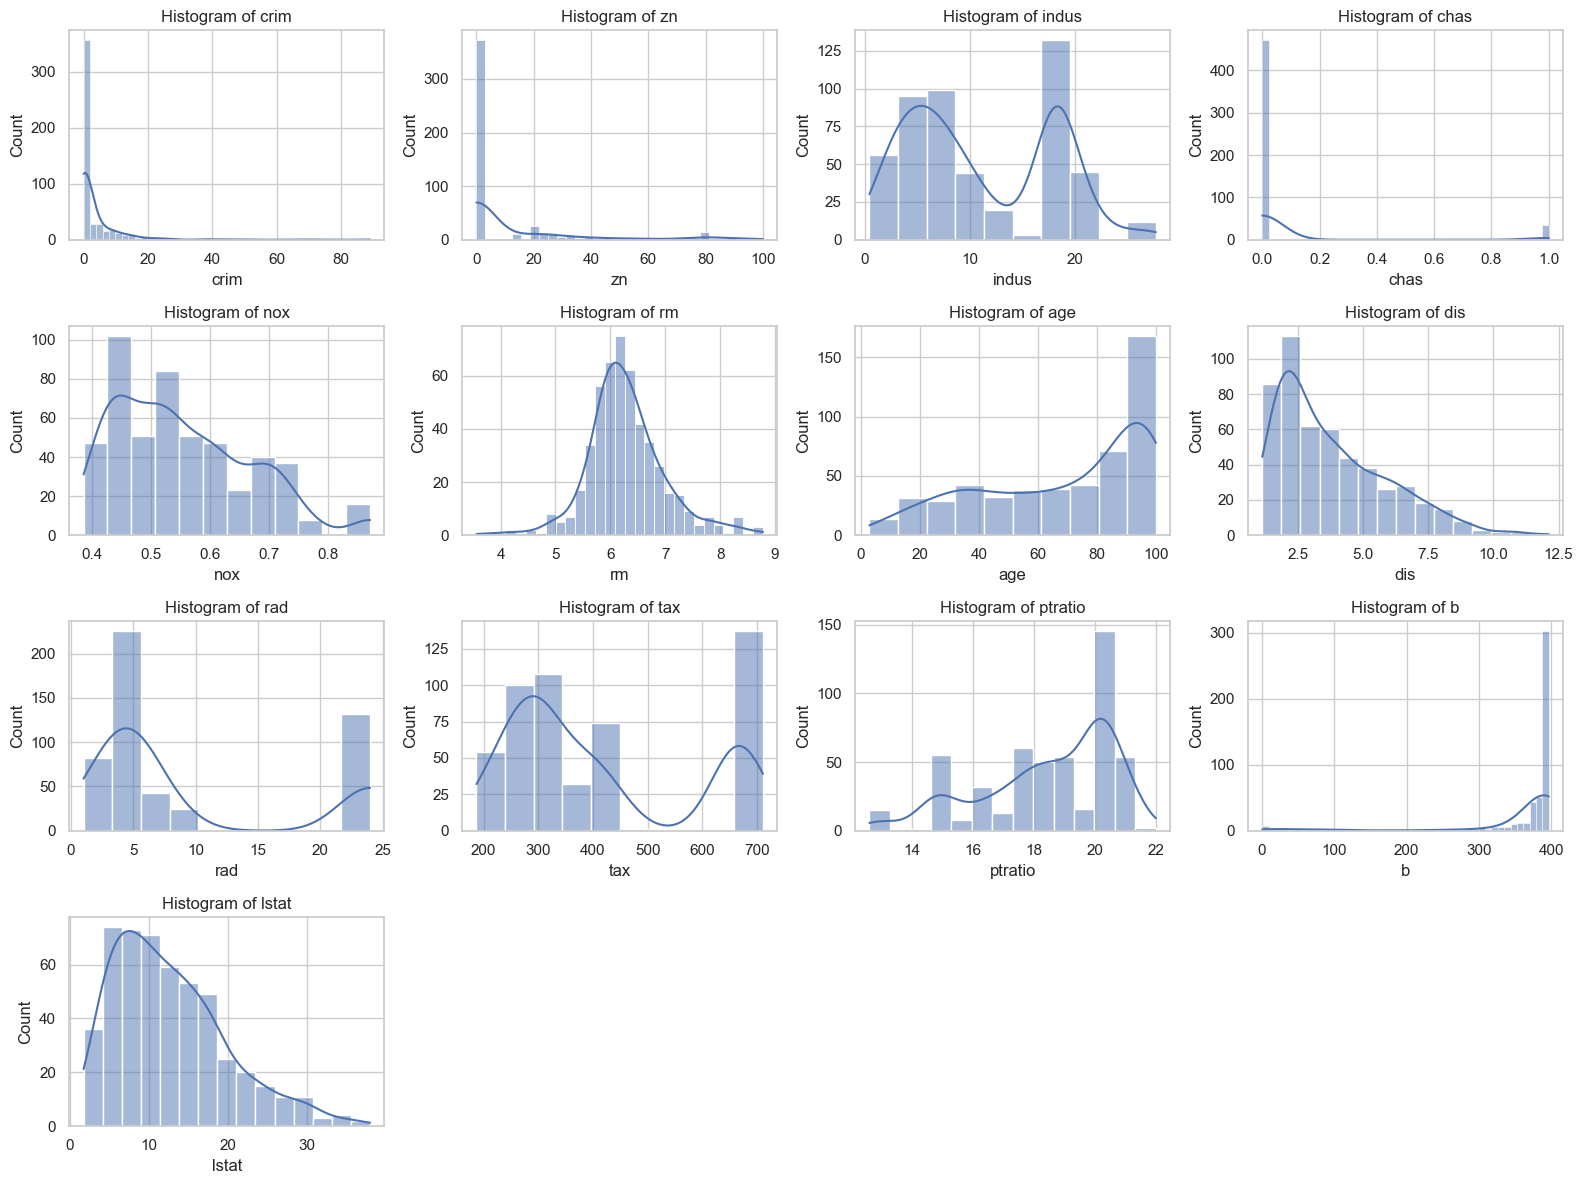

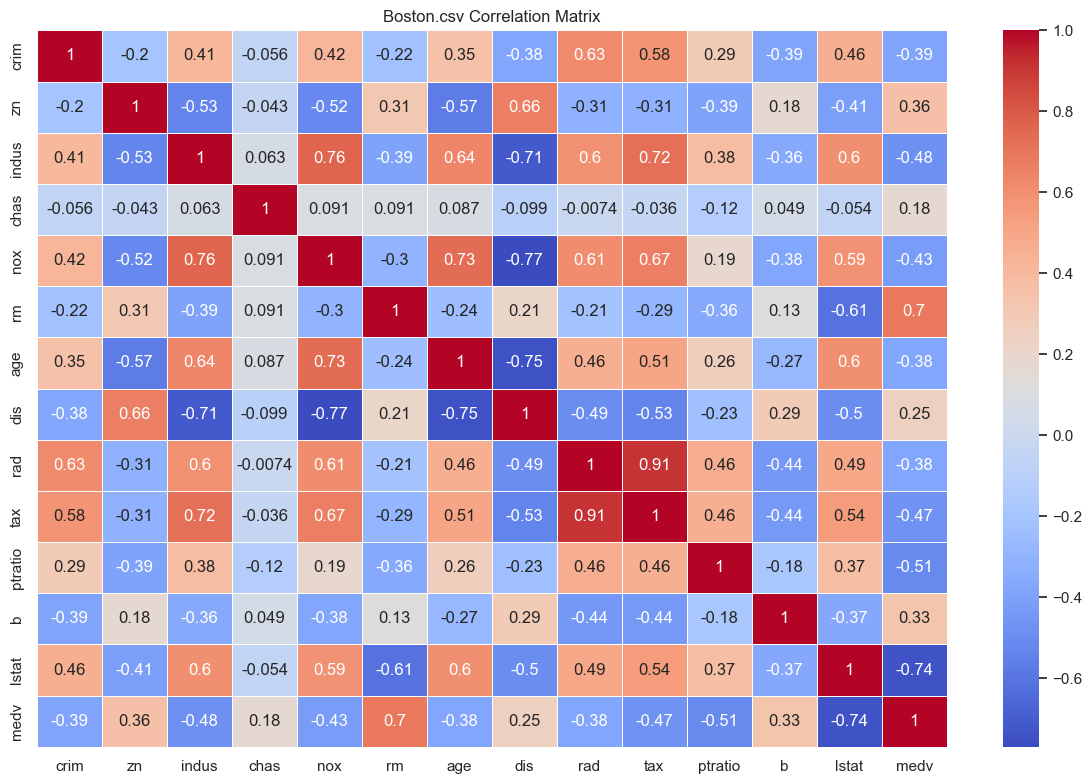

In [4]:
# Explore the data with visualisations such as histograms and correlation matrices

# Sets the style of the grid 
sns.set(style="whitegrid")

# List of the independent variables
indep_var = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']

# Create subplots for the histograms 
figure, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
figure.subplots_adjust(hspace=0.5)

# Flatten the 'axes' array to access individual subplots
axes = axes.ravel()

# Loop through the independant variables
for x, var in enumerate(indep_var):
    # Create histograms for the independant variables
    sns.histplot(pd.Series(data_boston[var]), ax=axes[x], kde=True)
    # Sets the title of the histograms 
    axes[x].set_title(f'Histogram of {var}')
    axes[x].set_xlabel(var)

# Hide the empty subplots
for x in range(len(indep_var), len(axes)):
    axes[x].axis('off')

# Adjusts the layout of the histograms 
plt.tight_layout()
# Display the histograms 
plt.show()


# Calculates the correlation matrix for all variables
correlation_matrix = data_boston[indep_var + ['medv']].corr()

# Create a heatmap for the correlation matrix
# Set the figure size for the heatmap
plt.figure(figsize=(12, 8))
# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
# Set the title for the heatmap
plt.title('Boston.csv Correlation Matrix')

# Adjust the layout of the plots 
plt.tight_layout()
# Display the plots 
plt.show()




In [5]:
# Split the independent variables from the dependent variable

independent = ['rm', 'lstat']
dependent = 'medv'

Text(0.5, 1.0, 'Histplot of medv vs. lstat')

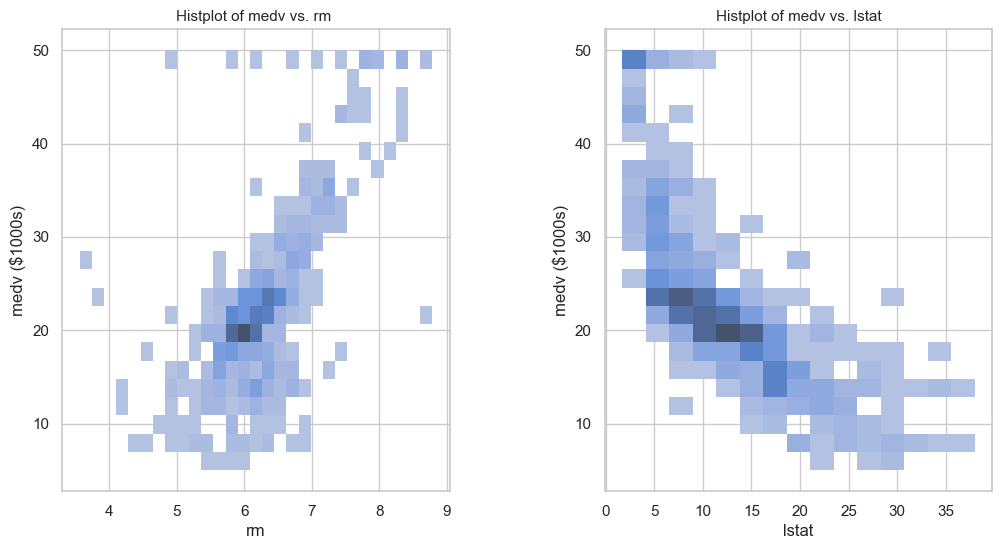

In [6]:
# Explore relationships between the independent and dependent variables

# Set the style of the grid
sns.set(style="whitegrid")

# Create subplots for histplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.subplots_adjust(hspace=0.5, wspace=0.4)

# Create a histplot for 'rm' vs. 'medv'
sns.histplot(data=data_boston, x='rm', y=dependent, ax=axes[0], kde=True)
axes[0].set_xlabel('rm')
axes[0].set_ylabel(f'{dependent} ($1000s)')
axes[0].set_title(f'Histplot of {dependent} vs. rm ', fontsize=11)

# Create a histplot for 'lstat' vs. 'medv'
sns.histplot(data=data_boston, x='lstat', y=dependent, ax=axes[1], kde=True)
axes[1].set_xlabel('lstat')
axes[1].set_ylabel(f'{dependent} ($1000s)')
axes[1].set_title(f'Histplot of {dependent} vs. lstat', fontsize=11)



In [7]:
# Create a training and test set with a 75:25 split ratio

X = data_boston[['rm', 'lstat']].values
y = data_boston['medv'].values

# Set the random seed for reproducibility
rseed = 15
# Split the data into a training set (75%) and a test set (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rseed)




In [8]:
# Build a multiple linear regression model using 'rm' and 'lstat'

lin_reg = LinearRegression()

lin_reg_boston_fit = lin_reg.fit(X_train, y_train)

In [9]:
# Print the model intercept and coefficients

print('Intercept: \n', lin_reg_boston_fit.intercept_)
print('Coefficients: \n', lin_reg_boston_fit.coef_)

Intercept: 
 -1.8118609616574304
Coefficients: 
 [ 5.16993249 -0.63910362]


In [10]:
# Generate predictions for the test set

predictions = lin_reg_boston_fit.predict(X_test)

print(predictions[0:5])


[26.1865098  37.82812973 17.60657076 24.32669547 26.41094298]


In [11]:
# Evaluate the model

MSE = mean_squared_error(y_test, predictions)

print(f'Mean Squared Error: {MSE:.4f}')



Mean Squared Error: 32.9887


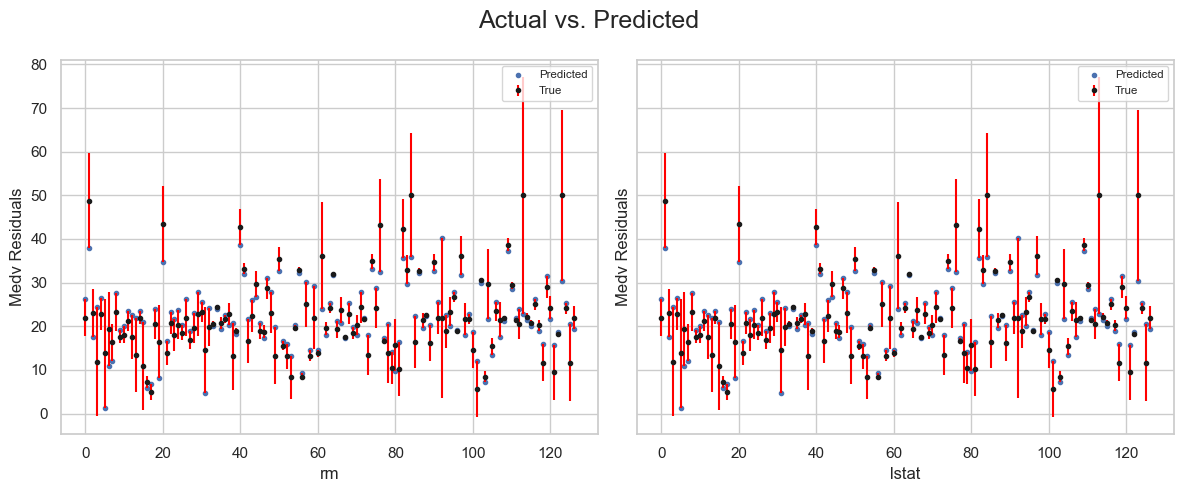

In [12]:

# Create an error plot with subplots
fig, ax = plt.subplots(1, X_test.shape[1], sharey=True, sharex=True, figsize=(12, 5))
fig.suptitle("Actual vs. Predicted ", fontsize=18)

# Set the labels for the subplots
for i in range(X_test.shape[1]):
    # Sets the xlabel as the name of an independent variable
    ax[i].set_xlabel(f'{independent[i]}')
    # Sets the ylabel as 'Medv Residuals'
    ax[i].set_ylabel(f'Medv Residuals')

    # Calculate the residual values 
    residual_values_dim = y_test - predictions

    # Calculate the absolute residuals for error bars
    error_bar_values = np.abs(residual_values_dim)

    # Plot data, predicted values, and error bars
    ax[i].errorbar(range(len(y_test)), y_test, yerr=error_bar_values, fmt='.k', ecolor='red', label='True')
    ax[i].scatter(range(len(y_test)), predictions, c='b', marker='.', label='Predicted') 
    ax[i].legend(loc='best', fontsize='x-small')

# Adjust the subplot layout for better spacing
plt.tight_layout()
# Displays the error plot
plt.show()





In [13]:
# Print the coefficients
print('Coefficients: \n', lin_reg_boston_fit.coef_)

Coefficients: 
 [ 5.16993249 -0.63910362]


**Interpret coefficients in the context of the prediction:**
[Answer here]
rm: The coefficient of 'rm' compared to 'medv' shows that 'rm' has a linear relationship with 'medv' meaning that as 'rm' increases so does 'medv'. This is clearly illustrated on the histplot comparing 'rm' to 'medv'. 'rm' would be a decent predictor of the median house values due to the linear relationship that the two variables share. As the number of rooms in a dwelling increases so does the median value of owner occupied homes.When comparing the coefficient to the predictions we can see that the predictions were mostly inaccurate, with a few errors being present on the error plot.

lstat: The coefficient of 'lstat' compared to 'medv' is negative, This means that as the value of 'lstat' increases the value of 'medv' decreases. The relationship is demonstrated well by the histplot comparing 'lstat' to 'medv'. When looking at the actual vs predicted values in the error plot we can see that the predictions somewhat accurate but there was still a large amount of errors present. In conclusion we can tell that status in the population does have an effect on median house values of owner-occupied homes.

**Summarise findings**
[Answer here]

There were no missing values present in the 'boston.csv' dataset.

The visualistations of the independant variables showed the following:

crim: It showed a decreasing count as the crime rate increased.

zn: Most residential land is not zoned for lots over 25,000 sq.ft.

indus: The proportion of non-retail business acres per town is very high, with a few outliers.

chas: Majority of the tracts did not bound the river.

nox: The mode for nitric oxide concentration fell between 0.4 and 0.5 parts per million.

rm: The average number of rooms per dwelling is 6 .

age: Most of the owner-occupied units were built prior to 1940.

dis: The mode for weighted distance to employment centers was 2.5

rad: The accesibility of radial highways is high in some areas and low in most areas.

tax: Property tax is very high in this area.

ptratio: The pupil to teacher rate is high in all towns, with the mode value being above 20.

b: The value is above 300 in all towns.

lstat: Majority of people dont fall into the lower status of the population. The count decreases as the percentage increases.


The heatmap was created to show the correlation between all the variables and I believe that it does so accurately.

The histplot of 'medv vs rm' shows a linear relationship between the two variables.

The histplot of 'medv vs lstat' shows that as the value of lstat increases, the value of medv decreases.

The Mean Squared Error value is 32.9887. This shows that the model has a significant amount of error. The model is partially accurate but there is still too many errors present.


The error plot shows the large amount of errors between the predicted and actual values

Overall the machine learning model created in this task would not be a very accurate way to predict the median house values in boston.